CPP Pricing Engine<br>
Alejandro Naranjo Caraza<br>
2026-03-01

#### Overview

In order to vertify the general functionality of the option pricing engine, the following code runs basic test cases for european and american options. It also tests edge cases, such as options with unerlying determinstic stock (zero volatility) and no stock yield (zero risk free interest rate). Examples of options with continuous dividend yield and known dividend cash schedule are also tested.

Each example compares prices obtained through Black-Scholes-Merton (BSM) model and through the binomial model for both call and put options. Convergence of the binomial model is also analyzed by plotting calculated price (y-axis) against the number of nodes used (x-axis).

Note that the option pricing models (BSM as well as binomial) depend on the following variables:

- T: Option time to maturity
- K: Option strike price
- Option Type: Call vs put option
- Exercise Type: American vs european
- S0: Current price of underlying asset
- r: Risk free annual rate
- q: Continuous dividend yield
- sigma: Stock volatility

All of the following test cases use the Cox-Ross-Rubinstein parameterization for $u, d, a$ in the binomial model.

#### Library Import

In [1]:
import math
import sys
sys.path.append('../cpp_pricing/build')
import pricer
import matplotlib.pyplot as plt

#### Global Functions
The following functions are used throughout this section to build stock, option and model objects from pricing parameters, as well as calculate the prices and plot results from the binomial model against the number of iterations used.

In [2]:
# Takes option and market parameters and prints out vanilla option price (Binomial Tree + BSM).
def getPrice(
    T,K,optType,exeType,
    S0,r,q,sigma,
    return_ = False,
    n=1000
):
    # Build option
    
    vanillaOption = pricer.makeVanillaOption(K,T,optType,exeType)
    
    # Bulild stock
    
    stock = pricer.makeStock(S0,q)    
    
    if exeType == 'e':

        # Build Binomial Model
            
        binomial = pricer.makeBinomial(vanillaOption,stock,r,sigma,n)
        
        # Build Black-Scholes-Metron model

        bsm = pricer.makeBSM(vanillaOption,stock,r,sigma)

        # Get vanilla option price through binomial tree (backwards induction)

        binomialPrice = binomial.getPrice()
        print("Price (Binomial): ",binomialPrice)

        # Get vanilla option price from Black-Scholes-Merton formula

        bsmPrice = bsm.getPrice()
        print("Price (BSM): ",bsmPrice)
    
    else:
        
        # Build Binomial Model
            
        binomial = pricer.makeBinomial(vanillaOption,stock,r,sigma,n)
        
        # Build Black-Scholes-Metron model
        
        european = pricer.makeVanillaOption(K,T,optType,'e')
        bsm = pricer.makeBSM(european,stock,r,sigma)
        
        # Get vanilla option price through binomial tree (backwards induction)

        binomialPrice = binomial.getPrice()
        print("Price (Binomial): ",binomialPrice)

        # Get vanilla option price from Black-Scholes-Merton formula

        bsmPrice = bsm.getPrice()
        print("Price (BSM): ",bsmPrice)
    
    if return_:
        
        return binomialPrice,bsmPrice
        
# Takes option and market parameters. Plots binomial tree price convergence as #iterations increase.
def plotBinomial(
    T,K,optType,exeType,
    S0,r,q,sigma,
):
    # Build option
    
    vanillaOption = pricer.makeVanillaOption(K,T,optType,exeType)
    
    # Bulild stock
    
    stock = pricer.makeStock(S0,q)
    
    numIters = []
    prices = []
    
    for n in range (1,26):
        numIters.append(n*20)
        binomial = pricer.makeBinomial(vanillaOption,stock,r,sigma,n*20)
        prices.append(binomial.getPrice())
    
    plt.plot(numIters,prices)
    plt.xlabel("Iterations / Time steps")
    plt.ylabel("Price")
    plt.title("Binomial Tree Convergence with Increase in Iterations")
    plt.show()

#### Example 1: Baseline
This is a traditional benchmark example (used in Hull, <i>Options, Futures and Other Derivatives</i>).<br>
Notice Binomial and BSM prices converge as we increase the number of nodes in the Binomial Model.

In [3]:
T = 1
K = 100
optType = 'c'
exeType = 'e'

S0 = 100
r = 0.05
q = 0

sigma = 0.2

In [4]:
getPrice(T,K,optType,exeType,S0,r,q,sigma)

Price (Binomial):  10.448584103764581
Price (BSM):  10.450583572185565


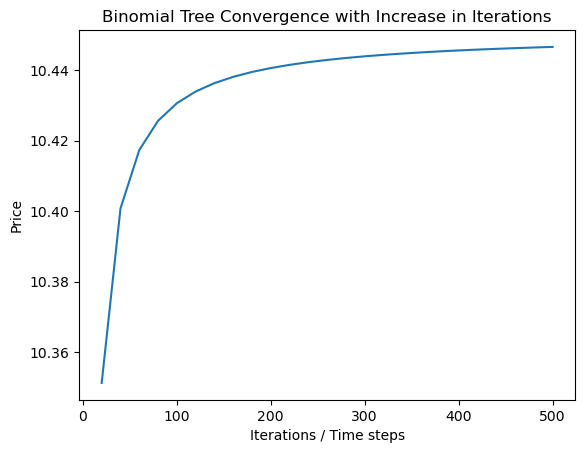

In [5]:
plotBinomial(T,K,optType,exeType,S0,r,q,sigma)

In [6]:
optType = 'p'

Price (Binomial):  5.57152655383364
Price (BSM):  5.573526022256971


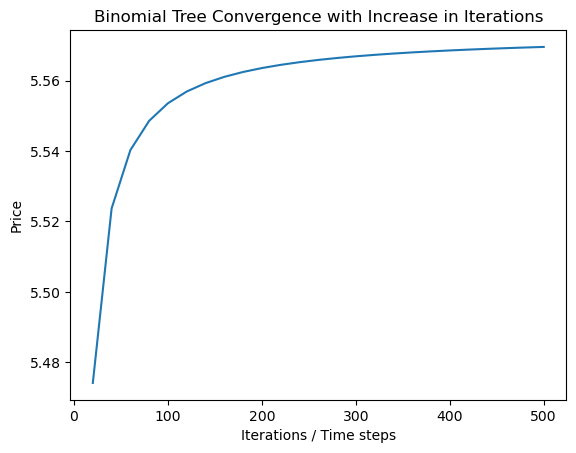

In [7]:
getPrice(T,K,optType,exeType,S0,r,q,sigma)
plotBinomial(T,K,optType,exeType,S0,r,q,sigma)

#### Example 2: Put-Call Parity
Test case to check put-call parity:
$$
C - P = S e^{-qT} - K e^{-rT}
$$

In [280]:
T = 2
K = 100
optType = 'c'
exeType = 'e'

S0 = 120
r = 0.03
q = 0

sigma = 0.25

Price (Binomial):  31.279687624099125
Price (BSM):  31.279802719901866


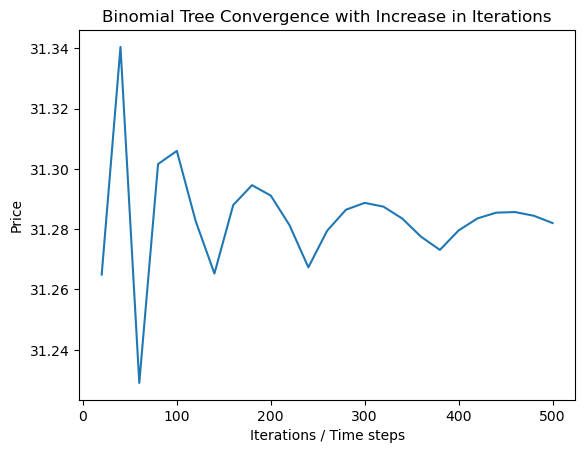

In [281]:
binomialCallPrice, bsmCallPrice = getPrice(T,K,optType,exeType,S0,r,q,sigma,True)
plotBinomial(T,K,optType,exeType,S0,r,q,sigma)

In [282]:
optType = 'p'

Price (Binomial):  5.456140982516954
Price (BSM):  5.456256078326742


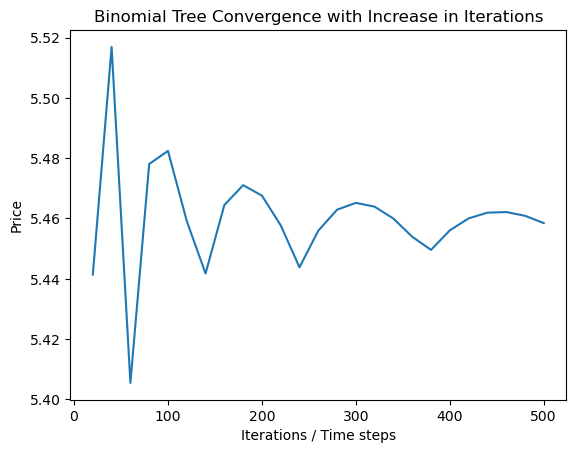

In [283]:
binomialPutPrice, bsmPutPrice = getPrice(T,K,optType,exeType,S0,r,q,sigma,True)
plotBinomial(T,K,optType,exeType,S0,r,q,sigma)

Notice put-call parity is satisfied:

In [285]:
print(binomialCallPrice - binomialPutPrice)
print(bsmCallPrice - bsmPutPrice)
print(S0 - K * math.exp(-r*T))

25.823546641582173
25.823546641575124
25.823546641575135


#### Example 3: Deep ITM Option
We consider a call option where strike price is well below the current underlying stock's price.<br>(Notice these options are generally more expensive because their strike price is favorable for current market conditions.)

In [287]:
T = 1
K = 100
optType = 'c'
exeType = 'e'

S0 = 200
r = 0.05
q = 0

sigma = 0.2

Price (Binomial):  104.8777156117045
Price (BSM):  104.87772423432371


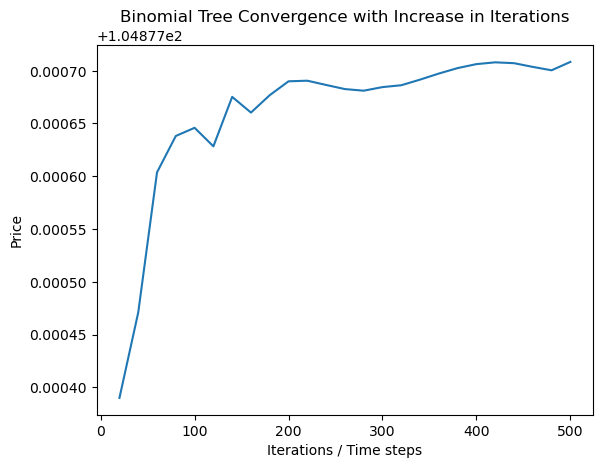

In [288]:
getPrice(T,K,optType,exeType,S0,r,q,sigma)
plotBinomial(T,K,optType,exeType,S0,r,q,sigma)

Notice that the put option equivalent (OTM) will be valued at a much lower price.

In [291]:
optType = 'p'

Price (Binomial):  0.0006580617751369543
Price (BSM):  0.0006666843951132258


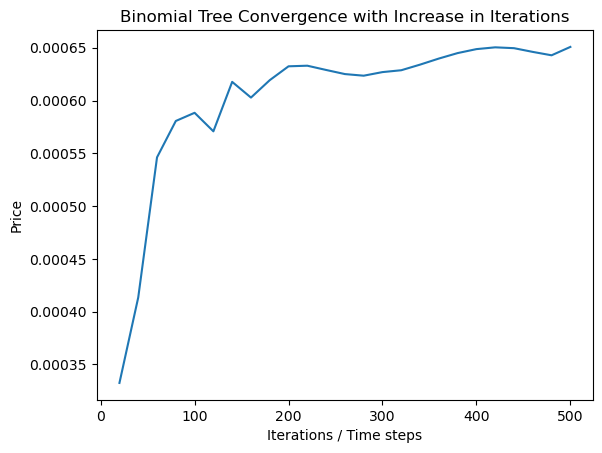

In [292]:
getPrice(T,K,optType,exeType,S0,r,q,sigma)
plotBinomial(T,K,optType,exeType,S0,r,q,sigma)

#### Example 4. Deep OTM Option
We consider the opposite case, where a call option's strike price is well above the current underlying stock's price.

In [297]:
T = 1
K = 100
optType = 'c'
exeType = 'e'

S0 = 50
r = 0.05
q = 0

sigma = 0.2

Price (Binomial):  0.002366016380139772
Price (BSM):  0.002399417553309663


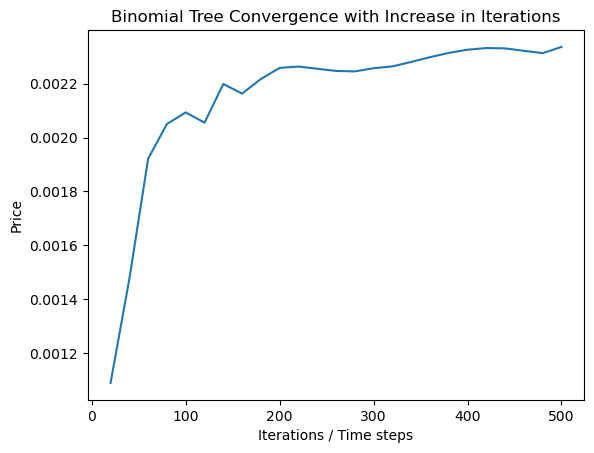

In [298]:
getPrice(T,K,optType,exeType,S0,r,q,sigma)
plotBinomial(T,K,optType,exeType,S0,r,q,sigma)

Notice that the put option equivalent (ITM) will be valued at a much higher price.

In [299]:
optType = 'p'

Price (Binomial):  45.12530846644839
Price (BSM):  45.12534186762472


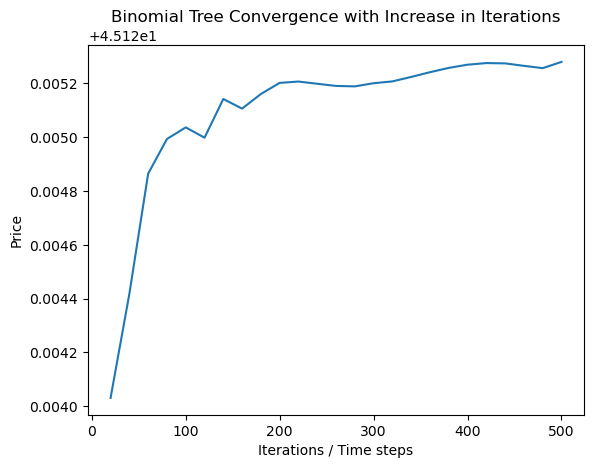

In [300]:
getPrice(T,K,optType,exeType,S0,r,q,sigma)
plotBinomial(T,K,optType,exeType,S0,r,q,sigma)

#### 5. Example: Zero Volatility
We consider a zero volatility (sigma=0) edge case.<br>
Notice that the binomial tree collapses into a fully deterministic system.

If the option is european, the price is the present value of the option's payoff, given that the underlying stock exhibits constant exponential growth (annual yield equivalent to risk free rate minus continuous dividend yield).

On the other hand, an american call option where the risk free rate is larger than the dividend yield will be exercised at maturity and its price is equivalent to the european option.

An american call option where the risk free rate is smaller than the dividend yield will be exercised immediately and the option's price is the payoff at <i>t=0</t>.

An american put option will also be exercised immediately and its price is equivalent to the option's payoff at <i>t=0</i>.

In [301]:
T = 1
K = 100
optType = 'c'
exeType = 'e'

S0 = 100
r = 0.05
q = 0

sigma = 0.0

Price (Binomial):  4.877057549928611
Price (BSM):  4.877057549928594


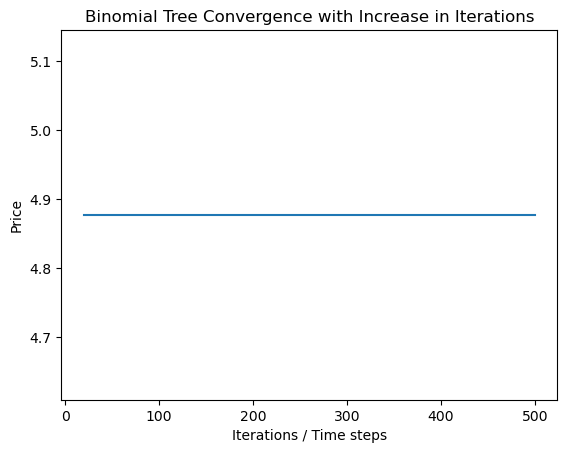

In [302]:
getPrice(T,K,optType,exeType,S0,r,q,sigma)
plotBinomial(T,K,optType,exeType,S0,r,q,sigma)

In [303]:
optType = 'p'

Price (Binomial):  0.0
Price (BSM):  0.0


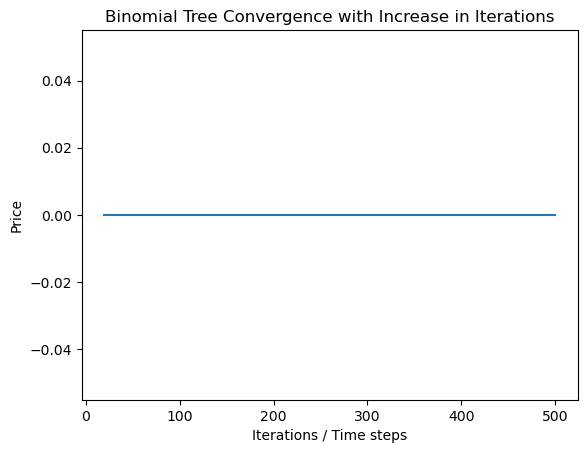

In [305]:
getPrice(T,K,optType,exeType,S0,r,q,sigma)
plotBinomial(T,K,optType,exeType,S0,r,q,sigma)

#### 6. Example: Zero Time to Maturity

We consider a zero time to maturity (T=0) edge case.<br>Notice that the option's price is its immediate payoff.

In [310]:
T = 0
K = 100
optType = 'c'
exeType = 'e'

S0 = 105
r = 0.05
q = 0.01

sigma = 0.2

Price (Binomial):  5.0
Price (BSM):  5.0


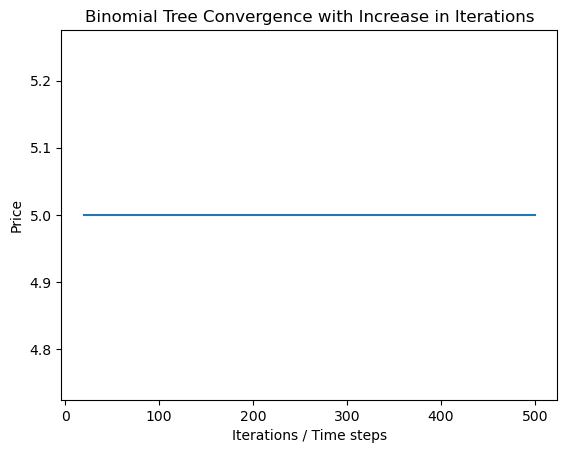

In [311]:
getPrice(T,K,optType,exeType,S0,r,q,sigma)
plotBinomial(T,K,optType,exeType,S0,r,q,sigma)

In [312]:
optType = 'p'

Price (Binomial):  0.0
Price (BSM):  0.0


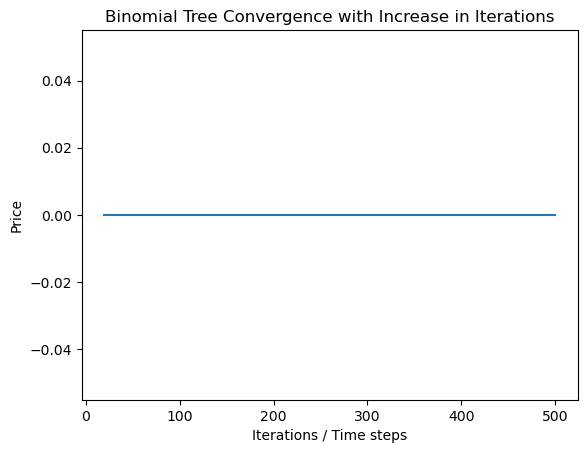

In [313]:
getPrice(T,K,optType,exeType,S0,r,q,sigma)
plotBinomial(T,K,optType,exeType,S0,r,q,sigma)

#### 7. Example: Zero Interest Rate
Consider zero interest rate edge case.<br>
Notice that models are still non-determinstic but without time value of money (future cash flows are worth the same as today's). Discounting disappears in both models.

In [315]:
T = 1
K = 100
optType = 'c'
exeType = 'e'

S0 = 100
r = 0
q = 0

sigma = 0.2

Price (Binomial):  7.9635763260249135
Price (BSM):  7.965567455405804


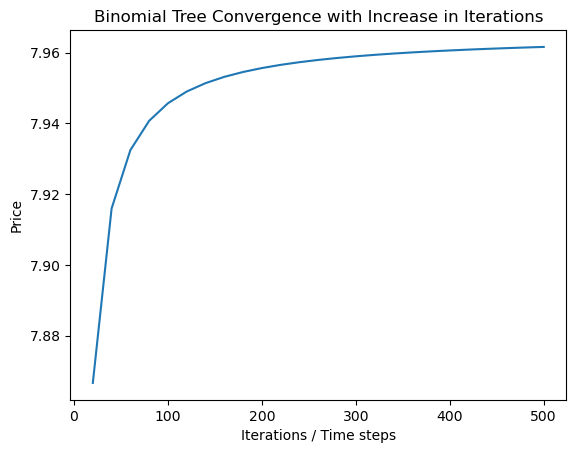

In [316]:
getPrice(T,K,optType,exeType,S0,r,q,sigma)
plotBinomial(T,K,optType,exeType,S0,r,q,sigma)

In [317]:
optType = 'p'

Price (Binomial):  7.963576326024925
Price (BSM):  7.965567455405804


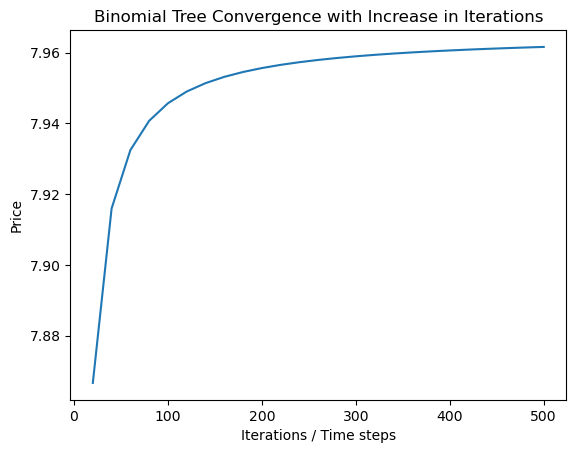

In [318]:
getPrice(T,K,optType,exeType,S0,r,q,sigma)
plotBinomial(T,K,optType,exeType,S0,r,q,sigma)

#### 8. Example: High Volatility
High volatility test for numerical stability.

In [319]:
T = 1
K = 100
optType = 'c'
exeType = 'e'

S0 = 100
r = 0.05
q = 0

sigma = 1.0

Price (Binomial):  39.830854144987555
Price (BSM):  39.84016248343717


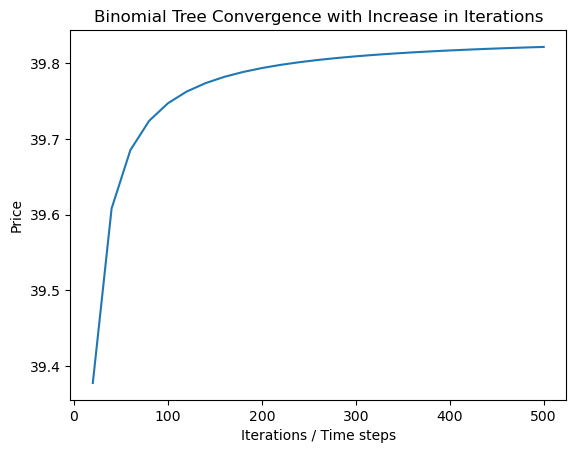

In [320]:
getPrice(T,K,optType,exeType,S0,r,q,sigma)
plotBinomial(T,K,optType,exeType,S0,r,q,sigma)

In [321]:
optType = 'p'

Price (Binomial):  34.953796595056566
Price (BSM):  34.963104933508575


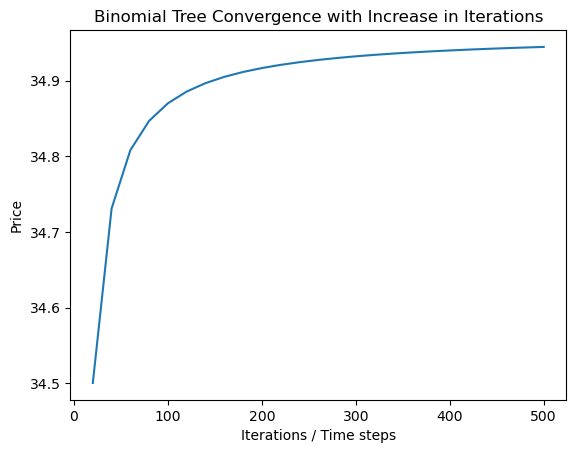

In [322]:
getPrice(T,K,optType,exeType,S0,r,q,sigma)
plotBinomial(T,K,optType,exeType,S0,r,q,sigma)

#### 9. Example: American Option
With american options, the option can be exercised at or before maturity.<br>

Notice that, in the case of a call option on a non-dividend paying asset, it will never be optimal to exercise before maturity, as holding the option preserves time value. Its price is equivalent to that of a european option.

In the case of an american put, it can be optimal to exercise before maturity, specially when the option is deep ITM. This means that the american put can often be more valuable than its european equivalent.

In [323]:
T = 1
K = 100
optType = 'c'
exeType = 'a'

S0 = 100
r = 0.05
q = 0

sigma = 0.2

Price (Binomial):  10.448584103764581
Price (BSM):  10.450583572185565


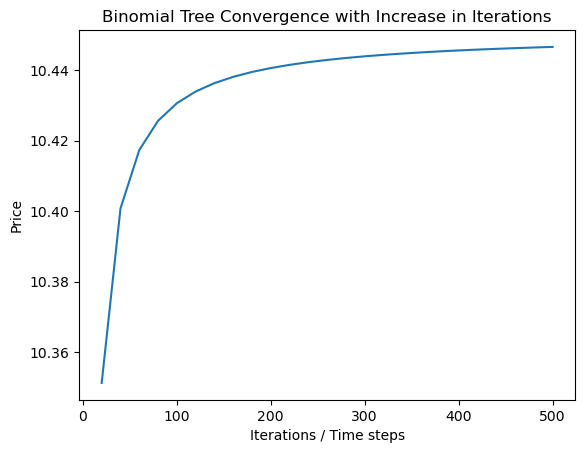

In [324]:
getPrice(T,K,optType,exeType,S0,r,q,sigma)
plotBinomial(T,K,optType,exeType,S0,r,q,sigma)

In [325]:
optType = 'p'

Price (Binomial):  6.089595282977866
Price (BSM):  5.573526022256971


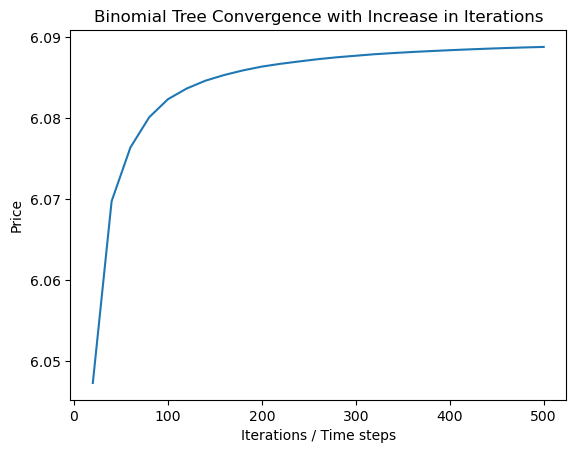

In [326]:
getPrice(T,K,optType,exeType,S0,r,q,sigma)
plotBinomial(T,K,optType,exeType,S0,r,q,sigma)

#### 10. Example: American Option

In [327]:
T = 1
K = 40
optType = 'p'
exeType = 'a'

S0 = 40
r = 0.06
q = 0

sigma = 0.2

Price (Binomial):  2.319278261909931
Price (BSM):  2.0664010044203422


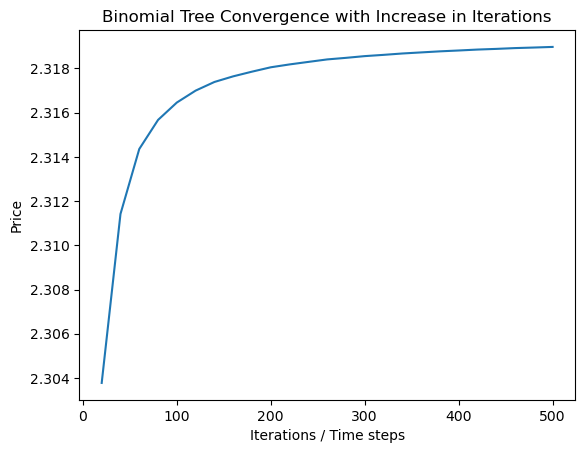

In [328]:
getPrice(T,K,optType,exeType,S0,r,q,sigma)
plotBinomial(T,K,optType,exeType,S0,r,q,sigma)

In [329]:
optType = 'c'

Price (Binomial):  4.395014477558624
Price (BSM):  4.395819661050393


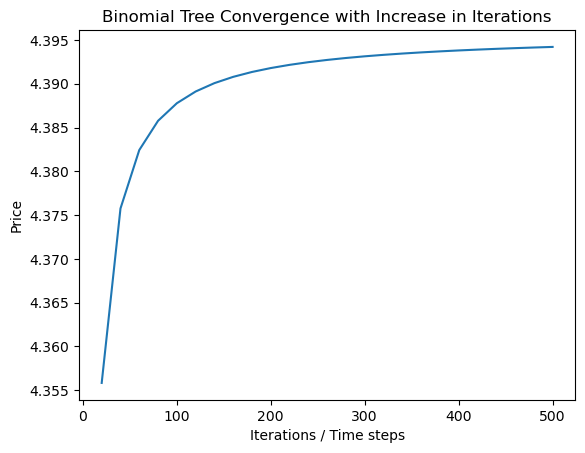

In [330]:
getPrice(T,K,optType,exeType,S0,r,q,sigma)
plotBinomial(T,K,optType,exeType,S0,r,q,sigma)

#### 11. Example: Binomial with Known Dividend Cash Schedule

For a european option with a known dividend schedule, expected dividend payments reduce the future price of the underlying asset. As a result, put options become more valuable relative to the non-dividend case, while call options become less valuable.

In [337]:
divCash = [
    [3.5/12,2.06]
]

T = 5 / 12
K = 50
optType = 'p'
exeType = 'a'

S0 = 52
r = 0.1
q = 0

sigma = 0.4
n = 1000

In [338]:
# Build option

american = pricer.makeVanillaOption(K,T,optType,exeType)
european = pricer.makeVanillaOption(K,T,optType,'e')

# Bulild stock

stock = pricer.makeStock(S0,q,divCash)

# Build binomial model

binomial = pricer.makeBinomial(american,stock,r,sigma,n)

# Build Black-Scholes-Metron model

bsm = pricer.makeBSM(european,stock,r,sigma)

In [341]:
# Get vanilla option price through binomial tree (backwards induction)

binomialPut = binomial.getPrice()
print("Option price with dividend cash schedule (binomial): ",binomialPut)

# Get vanilla option price from Black-Scholes-Merton formula

print("Option price without dividend cash schedule (BSM): ",bsm.getPrice())

Option price with dividend cash schedule (binomial):  4.219995934142615
Option price without dividend cash schedule (BSM):  3.362040105114886


In [342]:
optType = 'c'
n = 1000

In [343]:
# Build option

american = pricer.makeVanillaOption(K,T,optType,exeType)
european = pricer.makeVanillaOption(K,T,optType,'e')

# Bulild stock

stock = pricer.makeStock(S0,q,divCash)

# Build binomial model

binomial = pricer.makeBinomial(american,stock,r,sigma,n)

# Build Black-Scholes-Metron model

bsm = pricer.makeBSM(european,stock,r,sigma)

In [344]:
# Get vanilla option price through binomial tree (backwards induction)

binomialCall = binomial.getPrice()
print("Option price with dividend cash schedule (binomial): ",binomialCall)

# Get vanilla option price from Black-Scholes-Merton formula

print("Option price without dividend cash schedule (BSM): ",bsm.getPrice())

Option price with dividend cash schedule (binomial):  6.510884204925204
Option price without dividend cash schedule (BSM):  7.402567249657977
